In [1]:
pip install notebook ipykernel

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import joblib

print("=== TEST AHP + AI PIPELINE ===\n")

# =========================
# Load dataset
# =========================
df = pd.read_excel("AHP_Laptop_Nhom8.xlsx", sheet_name="Laptop_Data")
df.columns = df.columns.str.strip()

print("Dataset shape:", df.shape)

# =========================
# Load AI models
# =========================
performance_model = joblib.load("models/Performance_model.pkl")
portability_model = joblib.load("models/Portability_model.pkl")

print("Models loaded\n")

# =========================
# Features
# =========================
features = [
    "Norm_CPU",
    "Norm_RAM",
    "Norm_GPU",
    "Norm_Screen",
    "Norm_Weight",
    "Norm_Battery",
    "Norm_Durability"
]

X = df[features]

# =========================
# STEP 4: AI CHẤM ĐIỂM
# =========================
df["Performance_AI"] = performance_model.predict(X)
df["Portability_AI"] = portability_model.predict(X)

# hai tiêu chí này lấy trực tiếp
df["Battery_AI"] = df["Norm_Battery"]
df["Durability_AI"] = df["Norm_Durability"]

print("=== AI SCORES ===")
print(df[[
    "Performance_AI",
    "Portability_AI",
    "Battery_AI",
    "Durability_AI"
]].head())

# =========================
# STEP 5: TRỌNG SỐ AHP
# =========================
weights = {
    "performance": 0.45,
    "portability": 0.25,
    "battery": 0.20,
    "durability": 0.10
}

print("\n=== AHP WEIGHTS ===")
print(weights)

# =========================
# HYBRID MATCH SCORE
# =========================
df["MatchScore"] = (
    df["Performance_AI"] * weights["performance"]
    + df["Portability_AI"] * weights["portability"]
    + df["Battery_AI"] * weights["battery"]
    + df["Durability_AI"] * weights["durability"]
)

print("\n=== MATCH SCORE SAMPLE ===")
print(df[[
    "Performance_AI",
    "Portability_AI",
    "Battery_AI",
    "Durability_AI",
    "MatchScore"
]].head())

# =========================
# RANKING
# =========================
ranking = df.sort_values("MatchScore", ascending=False)

print("\n=== TOP 10 RECOMMENDED LAPTOPS ===\n")

print(ranking[[
    "Performance_AI",
    "Portability_AI",
    "Battery_AI",
    "Durability_AI",
    "MatchScore"
]].head(10))

print("\nPipeline OK: AI scoring + AHP ranking completed")

=== TEST AHP + AI PIPELINE ===



c:\Users\Khoa Dang\AppData\Local\Programs\Python\Python312\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)


Dataset shape: (1275, 43)
Models loaded

=== AI SCORES ===
   Performance_AI  Portability_AI  Battery_AI  Durability_AI
0         0.63978        0.212482         NaN            NaN
1         0.63978        0.212482         NaN            NaN
2         0.60119        0.186158    0.571429       0.690476
3         0.63978        0.212482         NaN            NaN
4         0.63978        0.212482         NaN            NaN

=== AHP WEIGHTS ===
{'performance': 0.45, 'portability': 0.25, 'battery': 0.2, 'durability': 0.1}

=== MATCH SCORE SAMPLE ===
   Performance_AI  Portability_AI  Battery_AI  Durability_AI  MatchScore
0         0.63978        0.212482         NaN            NaN         NaN
1         0.63978        0.212482         NaN            NaN         NaN
2         0.60119        0.186158    0.571429       0.690476    0.500408
3         0.63978        0.212482         NaN            NaN         NaN
4         0.63978        0.212482         NaN            NaN         NaN

=== TOP 1

c:\Users\Khoa Dang\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeRegressor from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\Khoa Dang\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator RandomForestRegressor from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

import joblib

print("Libraries loaded successfully!")

ModuleNotFoundError: No module named 'seaborn'

c:\Users\truc nguyen\AppData\Local\Programs\Python\Python311\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)


Dataset shape: (1275, 43)

===== MODEL EVALUATION =====
R2 Score: 0.8353599555875928
MAE: 0.01581245114882705
RMSE: 0.036411015230918484

===== FEATURE IMPORTANCE =====
Norm_RAM           0.516915
Norm_CPU           0.416985
Norm_GPU           0.029812
Price (VND)        0.021487
Norm_Weight        0.010043
Norm_Screen        0.004759
Norm_Battery       0.000000
Norm_Durability    0.000000
Norm_Upgrade       0.000000
dtype: float64


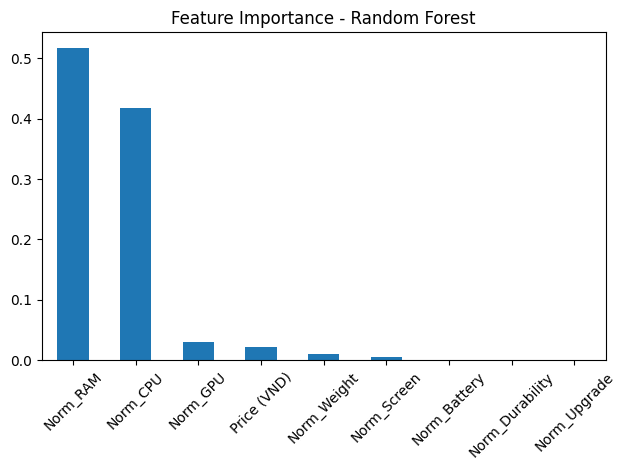

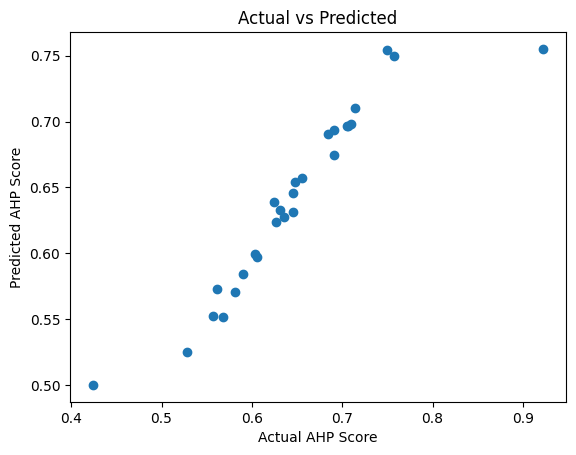


Model saved successfully!


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import joblib

# =============================
# 1. Load dữ liệu
# =============================
file_path = "AHP_Laptop_Nhom8.xlsx"

# SỬA sheet_name nếu cần
df = pd.read_excel(file_path, sheet_name="Laptop_Data")
df.columns = df.columns.str.strip()

print("Dataset shape:", df.shape)

# =============================
# 2. Chọn feature và target
# =============================
features = [
    "Norm_CPU", "Norm_RAM", "Norm_GPU",
    "Norm_Screen", "Norm_Weight",
    "Norm_Battery", "Norm_Durability",
    "Norm_Upgrade", "Price (VND)"
]

target = "AHP Score"

df = df.dropna(subset=features + [target])

X = df[features]
y = df[target]

# =============================
# 3. Chia train/test
# =============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# =============================
# 4. Train Random Forest
# =============================
model = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# =============================
# 5. Đánh giá model
# =============================
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\n===== MODEL EVALUATION =====")
print("R2 Score:", r2)
print("MAE:", mae)
print("RMSE:", rmse)

# =============================
# 6. Feature Importance
# =============================
importance = pd.Series(model.feature_importances_, index=features)
importance = importance.sort_values(ascending=False)

print("\n===== FEATURE IMPORTANCE =====")
print(importance)

plt.figure()
importance.plot(kind='bar')
plt.title("Feature Importance - Random Forest")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# =============================
# 7. So sánh Actual vs Predicted
# =============================
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual AHP Score")
plt.ylabel("Predicted AHP Score")
plt.title("Actual vs Predicted")
plt.show()

# =============================
# 8. Lưu model
# =============================
joblib.dump(model, "rf_ahp_model.pkl")
print("\nModel saved successfully!")

In [1]:
!pip install matplotlib seaborn scikit-learn openpyxl joblib

'C:\Users\truc nguyen\AppData\Local\Programs\Python\Python311\Scripts\pip.exe' was blocked by your organization's Device Guard policy.
Contact your support person for more info.
